Usage: To check coverage of DEMs, to fill in gaps when using several DEM tiles for prediction.

In [ ]:
import rasterio as rio 
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box
from shapely.ops import unary_union
import glob
import geopandas as gpd

In [10]:
paths = set()
bounds = []

dirs = ['../../../data/HillShade/Hatch/Hatch/*.tif',
        '../../../data/HillShade/Wells/*.tif',
        '../../../data/HillShade/BCCheddar/*.tif',
        '../../../data/HillShade/BCEast2/*.tif',
        '../../../data/HillShade/EastExt/East/*.tif',
        '../../../data/HillShade/HillShadeExtension/BCEast/*.tif',
        '../../../data/HillShade/BCSouth/*.tif',
        '../../../data/HillShade/South/*.tif'
        ]

for dir in dirs:
    files = glob.glob(dir)
    for p in files:
        try:
            with rio.open(p) as src:
                if p not in paths:
                    paths.update(p)
                    bounds.append(src.bounds)
        except:
            continue

In [ ]:
rects = [box(b.left, b.bottom, b.right, b.top) for b in bounds]
coverage = unary_union(rects)

# check if MultiPolygon
print(type(coverage))

<class 'shapely.geometry.multipolygon.MultiPolygon'>


In [12]:
total_extent = box(*coverage.bounds)
gaps = total_extent.difference(coverage)

if gaps.is_empty:
    print("no gaps")
else:
    print(f"gap area: {gaps.area /(5000 * 5000):.2f} tiles")

gap area: 40.00 tiles


/var/folders/fx/yls4l5xd4cdgs4b7gy2xpdv40000gn/T/ipykernel_6770/3199303993.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/fx/yls4l5xd4cdgs4b7gy2xpdv40000gn/T/ipykernel_6770/3199303993.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


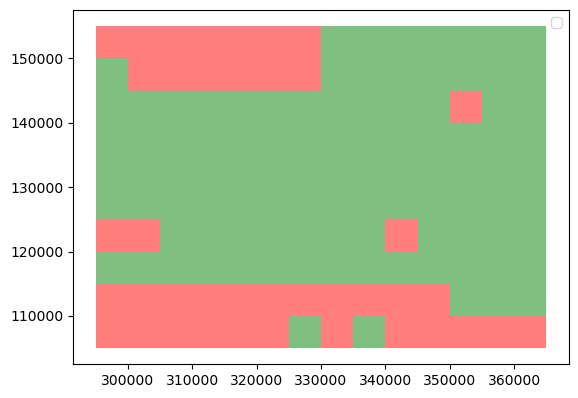

In [16]:
fig, ax = plt.subplots()
gpd.GeoSeries([coverage]).plot(ax=ax, color='green', alpha=0.5, label='coverage')
gpd.GeoSeries([gaps]).plot(ax=ax, color='red', alpha=0.5, label='gaps')
ax.legend()
plt.show()